In [1]:
import sys
sys.path.append('/Users/anyaphillips/Desktop/harvard/research/via_binaries/scripts')

import PETAR_ANALYSIS_FUNCTIONS as paf
import petar
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('vedant')
%matplotlib inline
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from astropy.table import Table
from scipy.stats import binned_statistic_2d

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib import gridspec
from matplotlib.lines import Line2D


from tqdm import tqdm

import pandas as pd

import astropy.constants as const
import astropy.units as u
from scipy.stats import binned_statistic
from matplotlib.gridspec import GridSpecFromSubplotSpec

import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap

lm_colors, hm_colors, simcolors = paf.define_simcolors()
time_cmap = paf.define_time_cmap()

Duplicate key in file PosixPath('/Users/anyaphillips/.matplotlib/stylelib/vedant.mplstyle'), line 46 ('lines.linewidth : 3')

Bad key hist.type in file /Users/anyaphillips/.matplotlib/stylelib/vedant.mplstyle, line 45 ('hist.type : step')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.0/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution
/opt/anaconda3/envs/petar_env3/lib/python3.10/site-packages/matplotlib_inline/config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


In [2]:
### load binaries: 

binaries = pd.read_csv('cosmic_example_IBC.csv')
N = len(binaries)
print(N)

15000


In [3]:
def calc_K(Mtot, M2, a, e, P, i):
    a1 = (M2/Mtot) * a

    num = 2*np.pi*a1 *np.sin(i)# nominally this would include sin(i)
    denom = P * np.sqrt(1-(e**2))
    K = num/denom # velocity semiamplitude - multiply by 2 for full amplitude.
    return K 

In [4]:
def calc_a(P, Mtot):
    """
    asdf
    """
    a = (P**2 * const.G * Mtot / (4*np.pi**2))**(1/3)
    return a

In [5]:
# do nominal mock observations
### stack orbital params. want v0 (km/s), K (km/s), w, phi0, e, P (day)
rng = np.random.default_rng(seed=42)

m1 = binaries['mass_1'].values * u.Msun
m2 = binaries['mass_2'].values * u.Msun
mtot = m1+m2
P = binaries['porb'].values * u.day # days
a = calc_a(P, mtot)

e = binaries['ecc'].values
i = paf.draw_inclinations(N, rng=rng)
K = calc_K(mtot, m2, a, e, P, i)
v0 = np.zeros(N)*(u.km/u.s)

w = rng.uniform(low=0, high=2*np.pi, size=N)
phi0 = rng.uniform(low=0, high=1, size=N)

params = np.array([
    v0.to(u.km/u.s).value,
    K.to(u.km/u.s).value, 
    w,
    phi0,
    e,
    P.to(u.day).value
]).T

In [ ]:
def get_obstimes(N, g1_l=30, g1_h=90, g2_l=3*365, g2_h=5*365, rng=None): 
    """
    for N stars, observe at some via like cadence set by g1/g2_l/h
    """

    if rng is None:
        rng = np.random.default_rng()

    base = np.repeat(0, N)
    gap1 = rng.uniform(g1_l,g1_h, size=N)
    gap2 = rng.uniform(g2_l, g2_h, size=N)

    deltaTs = np.vstack((base, gap1, gap2)).T

    obstimes_all = np.cumsum(deltaTs, axis=1) ##### THIS IS WHAT WILL GO INTO THE RV GENERATION FUNCTION!   
    return obstimes_all

def get_obstime(N, DT1, DT2):
    """
    the exact observing cadence version of the above. 
    i.e., observations will be separated by exactly DT1 and DT2.
    """
    base = np.repeat(0, N)
    gap1 = np.repeat(DT1, N)
    gap2 = np.repeat(DT2, N)

    deltaTs = np.vstack((base, gap1, gap2)).T
    obstimes_all = np.cumsum(deltaTs, axis=1) ##### THIS IS WHAT WILL GO INTO THE RV GENERATION FUNCTION!   
    return obstimes_all

In [93]:
rng = np.random.default_rng(seed=42)


#### loop through variable first visit lengths. 
dt1_vals  = np.arange(30, 90, 5) # 
dt2_vals = np.arange(365, 8*365, 365)

###### MAKE A NESTED LOOP HERE; MAKE SOME KIND OF COLOR PLOT OR SOMETHING. 

detection_fractions = []
for dt1_val in tqdm(dt1_vals):
    detection_fractions_this_dt1 = []
    for dt2_val in dt2_vals:
        obstimes = get_obstime(N=N, DT1=dt1_val, DT2=dt2_val)
        rvs = paf.get_rvs(params, obstimes, verbose=False)
        detected, delta_vsys = paf.get_detections(
                    0.1, # km/s
                    rvs,
                    v0, 
                    bool_arr='detet'
                )
        detection_fraction = len(P[detected])/len(P)
        detection_fractions_this_dt1.append(detection_fraction)
    detection_fractions.append(detection_fractions_this_dt1)

100%|██████████| 12/12 [00:59<00:00,  4.97s/it]


In [94]:
detection_fraction_array = np.array(detection_fractions)

In [103]:
current_example_iters = len(dt2_vals) * len(dt1_vals)

In [104]:
dt1_vals_test  = np.arange(5, 105, 5)
dt = 30
dt2_vals_test = np.arange(30, 5*365+dt, dt)

future_iters = len(dt1_vals_test)*len(dt2_vals_test)

In [ ]:
print(future_iters / current_example_iters) # not ... so bad ...? 

14.523809523809524


In [ ]:
# pickle and save to avoid running a 20 min long cell
# np.savetxt("detection_fractions.txt", detection_fraction_array)


dfa = np.loadtxt("detection_fractions.txt") # test... iek

In [96]:
detection_fraction_array.shape

(12, 7)

Text(0, 0.5, '$\\Delta T_2~\\rm [yr]$')

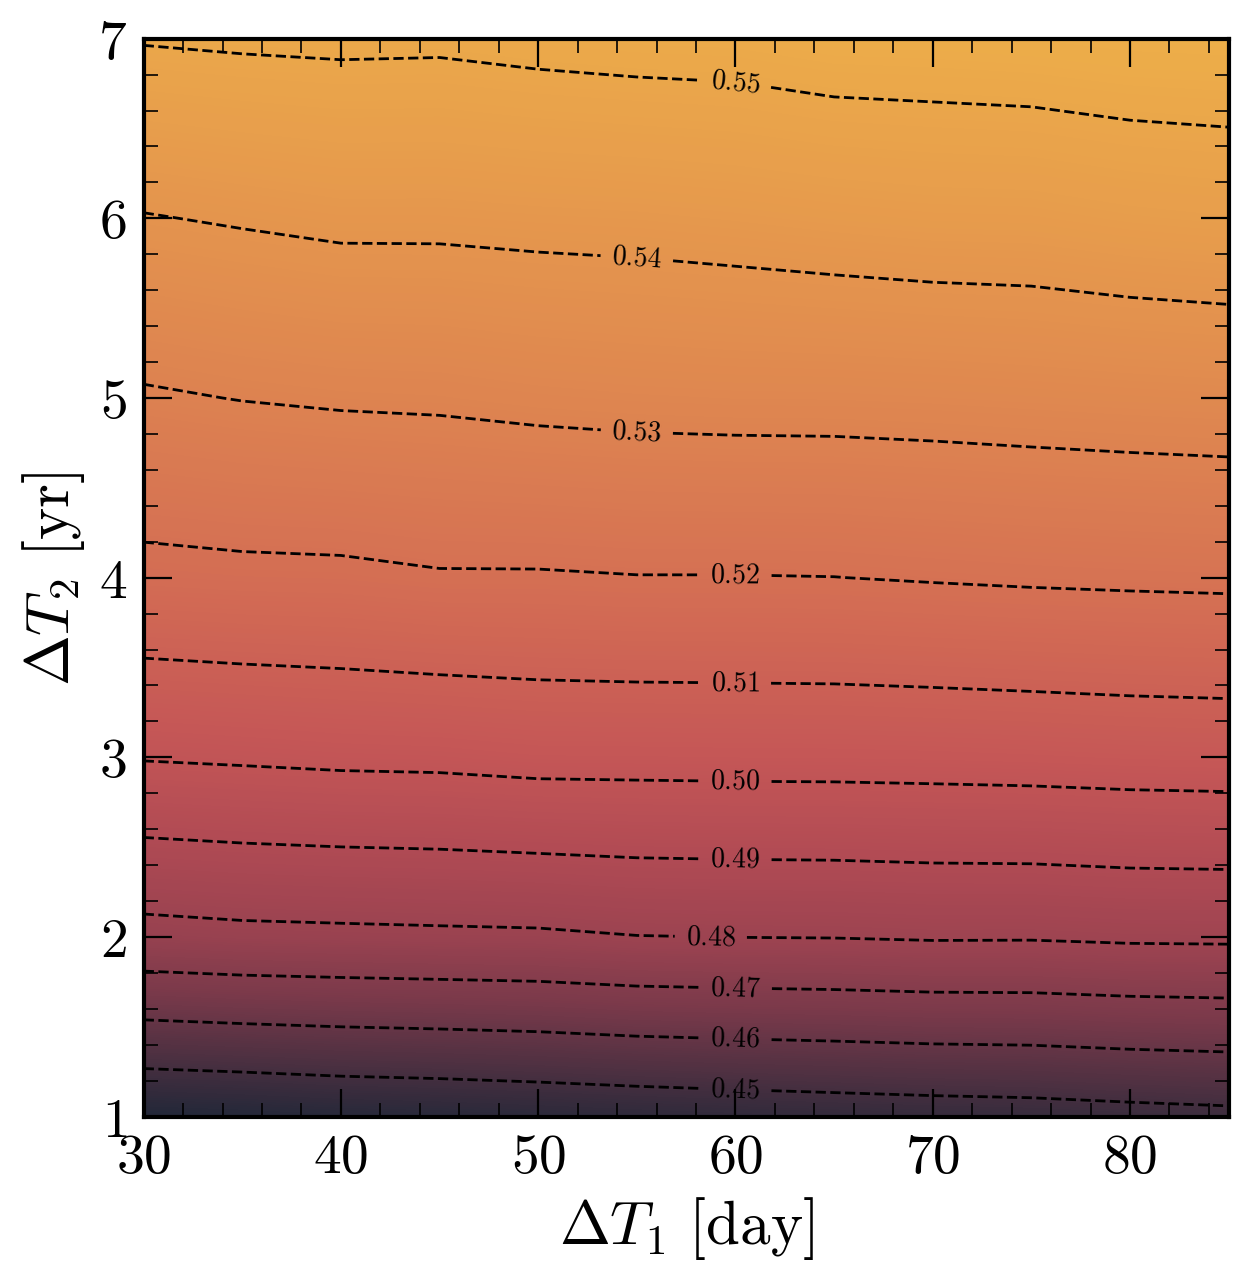

In [98]:
colors=["#212738","#4D3041","#79394A","#994250","#B24B54","#C55756","#D26A54","#DC8051","#E5974D","#EDAE49"]
# colors.reverse()
df_cmap = LinearSegmentedColormap.from_list('df_cmap', colors)

X, Y = np.meshgrid(dt1_vals, dt2_vals)
Z = dfa.T

Y = Y/365
fig, ax = plt.subplots()
# ax.imshow(dfa, cmap=time_cmap)
ob = ax.contourf(X,Y, Z, cmap=df_cmap, levels=1000)
divider = make_axes_locatable(ax)
# cax = divider.append_axes('right', size='5%', pad=0.05)
# cax.set_yticklabels(np.arange(0.44, 0.53, 0.01))
# fig.colorbar(ob, cax=cax, label=r"detection fraction")


ob = ax.contour(X,Y,Z, levels=np.arange(0.44, 0.55, 0.01),
           linestyles="dashed", colors="k", linewidths=1)
ax.clabel(ob, ob.levels, fontsize=10)

ax.set_xlabel(r"$\Delta T_1~\rm [day]$")
ax.set_ylabel(r'$\Delta T_2~\rm [yr]$')

In [76]:
plt.contour?

Signature: plt.contour(*args, data=None, **kwargs) -> 'QuadContourSet'
Docstring:
Plot contour lines.

Call signature::

    contour([X, Y,] Z, /, [levels], **kwargs)

The arguments *X*, *Y*, *Z* are positional-only.

`.contour` and `.contourf` draw contour lines and filled contours,
respectively.  Except as noted, function signatures and return values
are the same for both versions.

Parameters
----------
X, Y : array-like, optional
    The coordinates of the values in *Z*.

    *X* and *Y* must both be 2D with the same shape as *Z* (e.g.
    created via `numpy.meshgrid`), or they must both be 1-D such
    that ``len(X) == N`` is the number of columns in *Z* and
    ``len(Y) == M`` is the number of rows in *Z*.

    *X* and *Y* must both be ordered monotonically.

    If not given, they are assumed to be integer indices, i.e.
    ``X = range(N)``, ``Y = range(M)``.

Z : (M, N) array-like
    The height values over which the contour is drawn.  Color-mapping is
    controlled by *cmap*,

Text(0, 0.5, 'Binary Detection fraction')

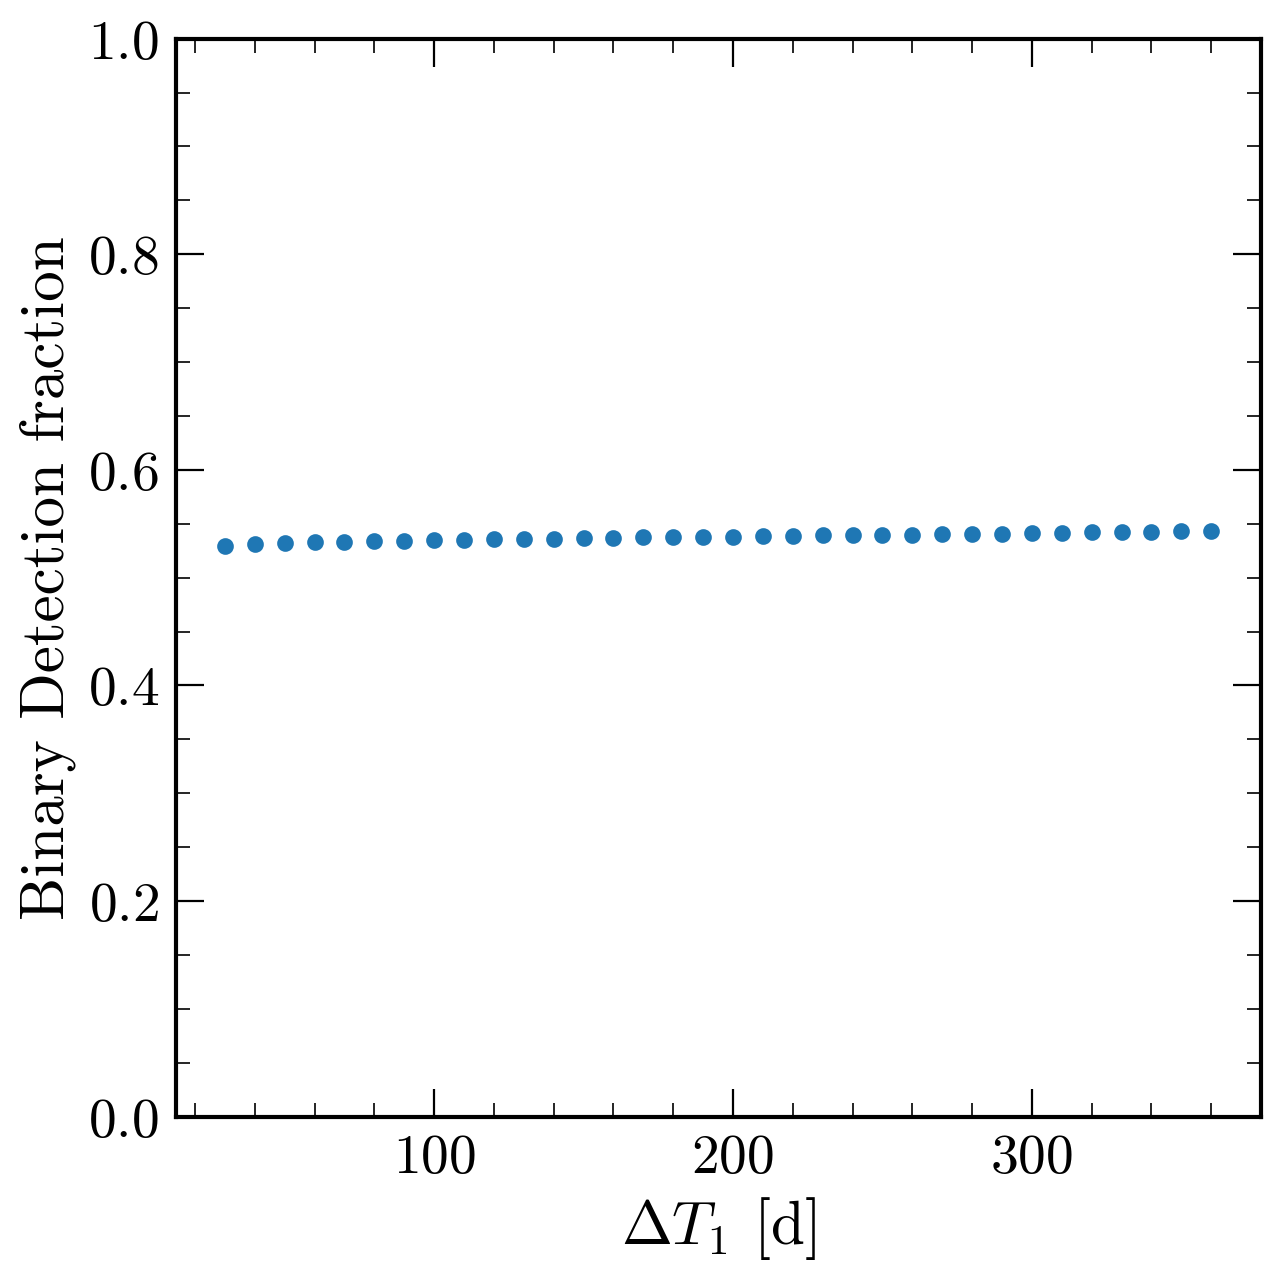

In [85]:
fig, ax = plt.subplots()
ax.scatter(visit_vals, detection_fractions)
ax.set_ylim(0,1)
ax.set_xlabel(r"$\Delta T_1$ [d]")
ax.set_ylabel(r'Binary Detection fraction')

In [86]:
rng = np.random.default_rng(seed=42)


#### loop through variable first visit lengths. 
visit_vals = np.arange(365, 5*365, 50)
detection_fractions = []
for iter, vv in enumerate(visit_vals):
    print("%i/%i"%(iter, len(visit_vals)-1))
    obstimes = get_obstime(N=N, DT1=30, DT2=vv)


    rvs = paf.get_rvs(params, obstimes)
    detected, delta_vsys = paf.get_detections(
        0.1, # km/s
        rvs,
        v0, 
        bool_arr='detet'
    )
    detection_fraction = len(P[detected])/len(P)
    # print(detection_fraction)
    detection_fractions.append(detection_fraction)


0/29


100%|██████████| 15000/15000 [00:00<00:00, 21239.20it/s]


1/29


100%|██████████| 15000/15000 [00:00<00:00, 20237.56it/s]


2/29


...

100%|██████████| 15000/15000 [00:00<00:00, 21433.50it/s]


28/29


100%|██████████| 15000/15000 [00:00<00:00, 20829.31it/s]


29/29


100%|██████████| 15000/15000 [00:00<00:00, 21426.95it/s]


Text(0, 0.5, 'Binary Detection fraction')

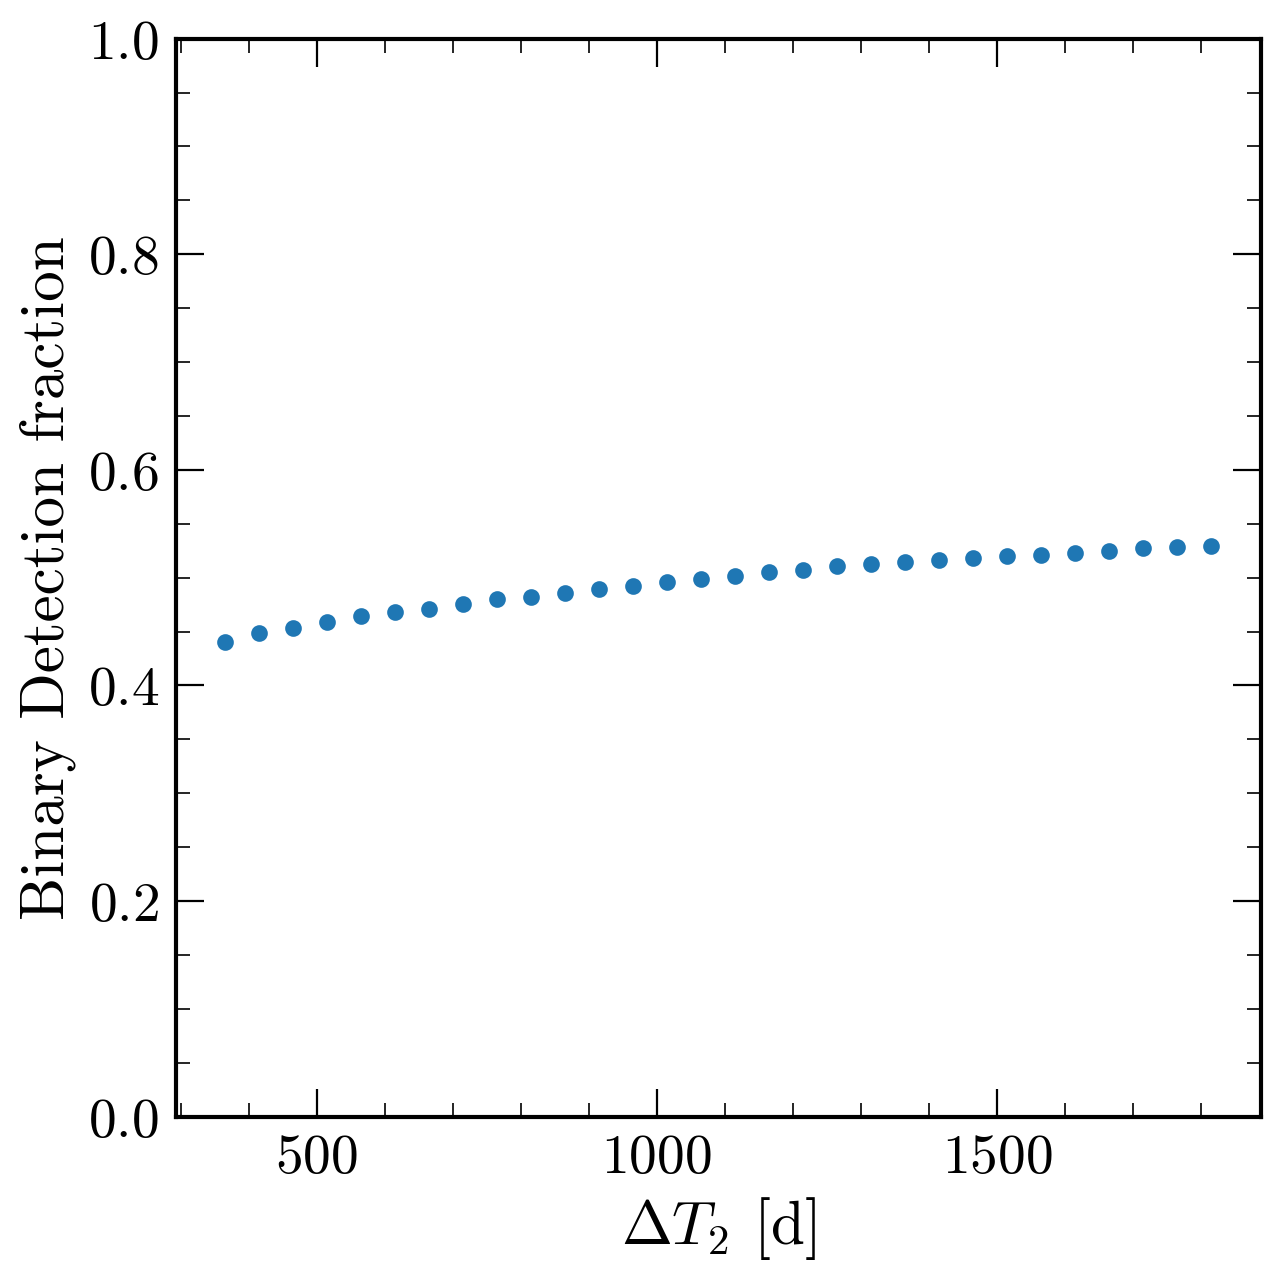

In [87]:
fig, ax = plt.subplots()
ax.scatter(visit_vals, detection_fractions)
ax.set_ylim(0,1)
ax.set_xlabel(r"$\Delta T_2$ [d]")
ax.set_ylabel(r'Binary Detection fraction')

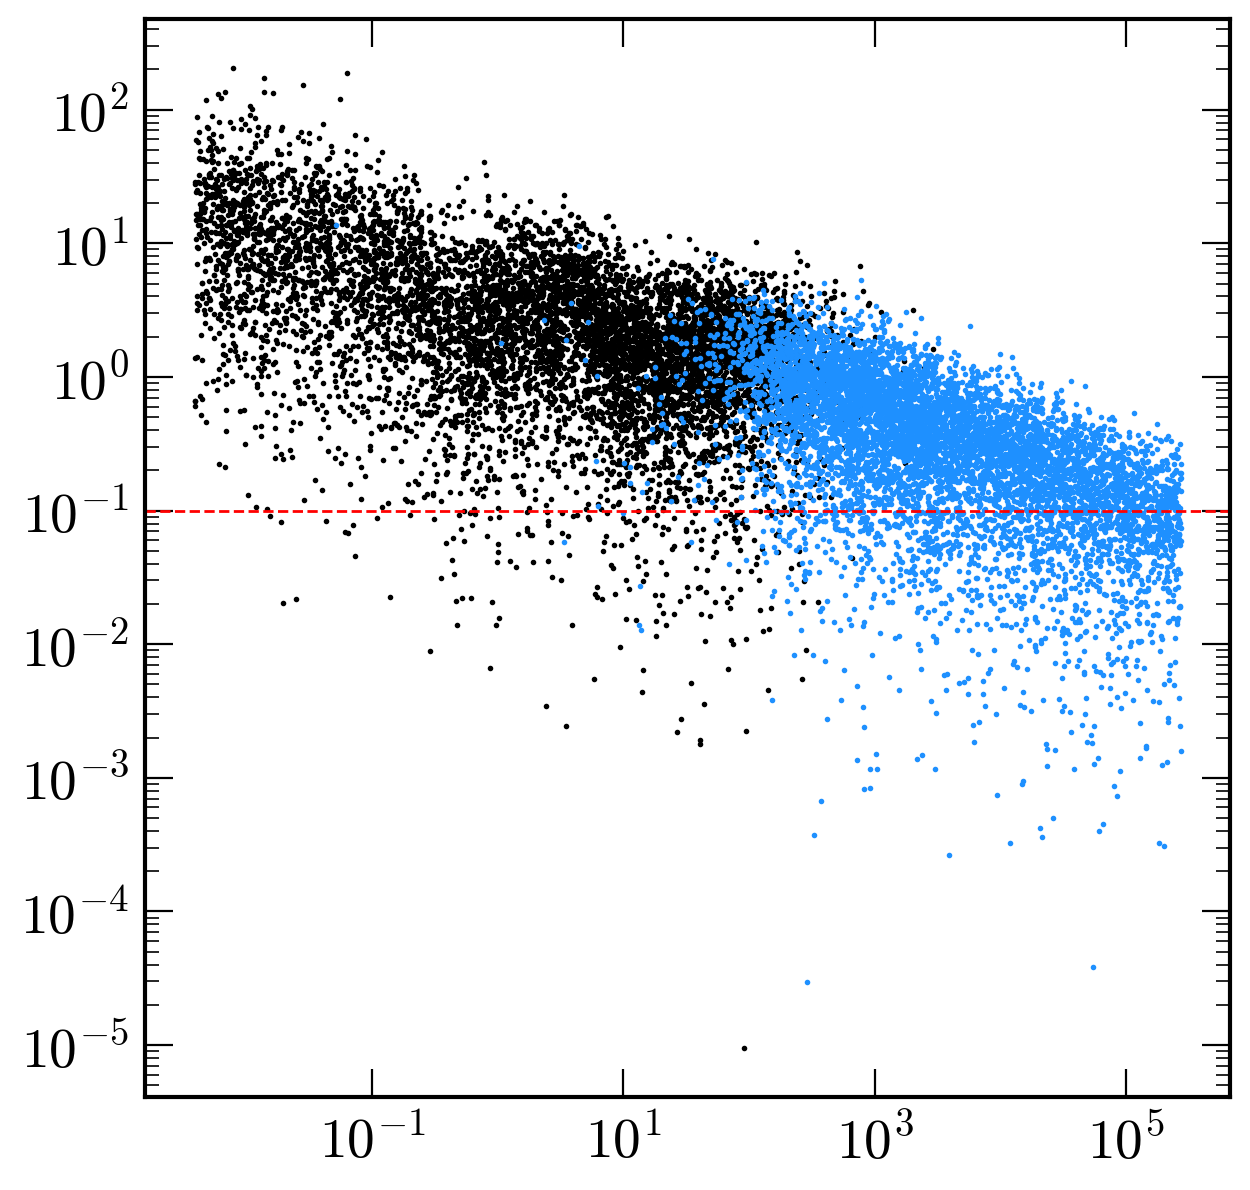

In [64]:
fig, ax = plt.subplots()
ax.scatter(P.to(u.yr)[detected], delta_vsys[detected], c='k', s=1)
ax.scatter(P.to(u.yr)[~detected], delta_vsys[~detected], c='dodgerblue', s=1)
ax.axhline(0.1, c='r', lw=1, ls='--')

ax.set_yscale('log')
ax.set_xscale('log')